# Mesh Tutorial 6: Integration with ML Workflows

This tutorial covers advanced topics for using PhysicsNeMo-Mesh in ML pipelines:

1. **Performance Benchmarks**: PhysicsNeMo-Mesh (GPU) vs PyVista/VTK (CPU)
2. **GPU Acceleration Benefits**: When and how much speedup to expect
3. **Batching Meshes**: Padding for torch.compile compatibility
4. **Feature Extraction**: Preparing mesh data for ML models
5. **Boundary Condition Handling**: Storing BC metadata in TensorDict
6. **End-to-End Workflow**: Complete CAE preprocessing example

---

## Why Replace PyVista/VTK in ML Pipelines?

Traditional mesh libraries like PyVista and VTK are excellent tools for visualization and
interactive exploration, but they are fundamentally CPU-bound:

- **CPU-GPU transfers**: Data must be copied to GPU for each training step
- **GIL bottleneck**: Python's Global Interpreter Lock limits parallelism
- **Per-element APIs**: Many operations (e.g., neighbor queries) only expose single-element functions
- **No autograd**: Cannot backpropagate through mesh operations

In large physics-AI training pipelines, mesh preprocessing and ETL can easily become the
bottleneck. When training on millions of mesh samples, even small per-sample overheads compound.

PhysicsNeMo-Mesh addresses these limitations:
- **GPU-native**: All operations are vectorized PyTorch, running natively on CUDA
- **Differentiable**: Seamless integration with PyTorch autograd
- **Batch operations**: Compute neighbors, samples, and features for all elements at once
- **TensorDict-based**: Efficient batching and device management

By moving mesh operations to GPU, we also enable **post-load feature engineering** that would
previously be prohibitively slow - opening opportunities for physics-aware model architectures
that compute geometric features on-the-fly during training.

In [ ]:
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import torch
from tensordict import TensorDict

from physicsnemo.mesh import Mesh
from physicsnemo.mesh.calculus import compute_gradient_points_lsq
from physicsnemo.mesh.io import from_pyvista, to_pyvista
from physicsnemo.mesh.smoothing import smooth_laplacian

/home/psharpe/gh/physicsnemo/physicsnemo/core/filesystem.py:76: SyntaxWarning: invalid escape sequence '\w'
  pattern = re.compile(f"{suffix}[\w-]+(/[\w-]+)?/[\w-]+@[A-Za-z0-9.]+/[\w/](.*)")


In [2]:
### System Information

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)
print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"PyVista: {pv.__version__}")
print(f"CPU: {platform.processor() or platform.machine()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Memory: {gpu_mem:.1f} GB")
else:
    print("GPU: Not available (benchmarks will run on CPU only)")
print("=" * 60)

SYSTEM INFORMATION
Python: 3.13.8
PyTorch: 2.10.0+cu130
PyVista: 0.46.5
CPU: x86_64
GPU: NVIDIA GeForce RTX 4090 Laptop GPU
CUDA: 13.0
GPU Memory: 17.2 GB


## Section 1: Performance Benchmarks

We compare PhysicsNeMo-Mesh (GPU) to PyVista/VTK (CPU) across several common mesh operations.
All benchmarks use the Stanford Bunny mesh at various subdivision levels. We always use
`to_pyvista(pnm_mesh)` to ensure both libraries operate on identical geometry.

**Operations benchmarked:**
- Normal computation
- Curvature computation
- Subdivision (Loop scheme)
- Neighbor computation (point-to-point, cell-to-cell)
- Random point sampling
- Laplacian smoothing
- Geometric transformations

In [3]:
def benchmark(
    name: str,
    func,
    n_runs: int = 10,
    warmup: int = 3,
    verbose: bool = True,
    setup: callable = None,
):
    """Benchmark a function and return the minimum time.

    Using minimum (not mean) is standard practice for benchmarks because it
    represents the best achievable performance without system noise.

    Parameters
    ----------
    name : str
        Display name for the benchmark.
    func : callable
        Function to benchmark.
    n_runs : int
        Number of timed runs.
    warmup : int
        Number of warmup runs (not timed).
    verbose : bool
        Whether to print results.
    setup : callable, optional
        Function to call before each run (not included in timing).
        Use this to strip caches from meshes to prevent false performance benefits.
    """
    # Warmup runs
    for _ in range(warmup):
        if setup is not None:
            setup()
        func()

    # Timed runs with proper CUDA synchronization
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        # Run setup (cache stripping) before timing
        if setup is not None:
            setup()

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()
        result = func()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.perf_counter() - start)

    min_time = min(times)
    if verbose:
        print(f"{name}: {min_time * 1000:.3f} ms")
    return min_time, result


# Store benchmark results for final visualization
benchmark_results = {}

### Load the Bunny Mesh

We use the Stanford Bunny at increasing subdivision levels to demonstrate scaling behavior.
Higher subdivision levels amortize CUDA kernel launch overhead, showing the true GPU advantage.

In [4]:
# Load the base bunny mesh and create subdivision variants
bunny_base = torch.load("assets/bunny.pt", weights_only=False)

# Create meshes at increasing subdivision levels
# Level 0 = base mesh, Level 3 = highly refined (100k+ cells)
subdivision_levels = [0, 1, 2, 3, 4, 5, 6]
meshes = {}

print("Mesh sizes at each subdivision level:")
print("-" * 50)
for level in subdivision_levels:
    if level == 0:
        meshes[level] = bunny_base.clone()
    else:
        meshes[level] = bunny_base.subdivide(levels=level, filter="loop")
    m = meshes[level]
    print(f"  Level {level}: {m.n_points:,} points, {m.n_cells:,} cells")

Mesh sizes at each subdivision level:
--------------------------------------------------
  Level 0: 400 points, 796 cells
  Level 1: 1,594 points, 3,184 cells
  Level 2: 6,370 points, 12,736 cells
  Level 3: 25,474 points, 50,944 cells
  Level 4: 101,890 points, 203,776 cells
  Level 5: 407,554 points, 815,104 cells
  Level 6: 1,630,210 points, 3,260,416 cells


### Normal Computation

Computing surface normals is a fundamental operation for rendering, physics simulation, and
ML feature extraction. PyVista calls VTK's CPU-based normal computation; PhysicsNeMo-Mesh
uses vectorized PyTorch operations.

In [5]:
print("Normal Computation Benchmark")
print("=" * 60)

benchmark_results["normals"] = {"pyvista": [], "pnm_gpu": [], "sizes": []}

for level in subdivision_levels:
    pnm_mesh = meshes[level]
    pv_mesh = to_pyvista(pnm_mesh)  # Same geometry for fair comparison

    print(f"\nLevel {level}: {pnm_mesh.n_points:,} points, {pnm_mesh.n_cells:,} cells")
    benchmark_results["normals"]["sizes"].append(pnm_mesh.n_cells)

    # PyVista (CPU) - VTK backend
    def pyvista_normals():
        return pv_mesh.compute_normals(cell_normals=True, point_normals=False)

    pv_time, _ = benchmark("  PyVista (CPU)", pyvista_normals)
    benchmark_results["normals"]["pyvista"].append(pv_time)

    # PhysicsNeMo-Mesh (GPU)
    if torch.cuda.is_available():
        # Use a mutable container so setup can update the mesh reference
        mesh_holder = [pnm_mesh.to("cuda")]

        def strip_cache():
            mesh_holder[0] = mesh_holder[0].strip_caches()

        def pnm_gpu_normals():
            return mesh_holder[0].cell_normals

        pnm_gpu_time, _ = benchmark(
            "  PhysicsNeMo (GPU)", pnm_gpu_normals, setup=strip_cache
        )
        benchmark_results["normals"]["pnm_gpu"].append(pnm_gpu_time)
        print(f"  Speedup: {pv_time / pnm_gpu_time:.1f}x")

Normal Computation Benchmark

Level 0: 400 points, 796 cells
  PyVista (CPU): 0.911 ms
  PhysicsNeMo (GPU): 1.669 ms
  Speedup: 0.5x

Level 1: 1,594 points, 3,184 cells
  PyVista (CPU): 1.413 ms
  PhysicsNeMo (GPU): 1.570 ms
  Speedup: 0.9x

Level 2: 6,370 points, 12,736 cells
  PyVista (CPU): 3.174 ms
  PhysicsNeMo (GPU): 1.337 ms
  Speedup: 2.4x

Level 3: 25,474 points, 50,944 cells
  PyVista (CPU): 10.737 ms
  PhysicsNeMo (GPU): 1.416 ms
  Speedup: 7.6x

Level 4: 101,890 points, 203,776 cells
  PyVista (CPU): 38.170 ms
  PhysicsNeMo (GPU): 1.379 ms
  Speedup: 27.7x

Level 5: 407,554 points, 815,104 cells
  PyVista (CPU): 154.964 ms
  PhysicsNeMo (GPU): 1.510 ms
  Speedup: 102.6x

Level 6: 1,630,210 points, 3,260,416 cells
  PyVista (CPU): 826.381 ms
  PhysicsNeMo (GPU): 5.518 ms
  Speedup: 149.8x


### Curvature Computation

Gaussian curvature measures local surface bending. This is computed from vertex angles and areas.
PyVista/VTK does not have a direct Gaussian curvature function, so we compare CPU vs GPU within
PhysicsNeMo-Mesh only.

In [6]:
print("Curvature Computation Benchmark")
print("=" * 60)

benchmark_results["curvature"] = {"pnm_cpu": [], "pnm_gpu": [], "sizes": []}

for level in subdivision_levels[1:]:  # Skip level 0 (too small)
    pnm_mesh = meshes[level]

    print(f"\nLevel {level}: {pnm_mesh.n_points:,} points")
    benchmark_results["curvature"]["sizes"].append(pnm_mesh.n_points)

    # PhysicsNeMo-Mesh (CPU)
    def pnm_cpu_curvature():
        return pnm_mesh.gaussian_curvature_vertices

    pnm_cpu_time, _ = benchmark("  PhysicsNeMo (CPU)", pnm_cpu_curvature)
    benchmark_results["curvature"]["pnm_cpu"].append(pnm_cpu_time)

    # PhysicsNeMo-Mesh (GPU)
    if torch.cuda.is_available():
        pnm_gpu_mesh = pnm_mesh.to("cuda")

        def pnm_gpu_curvature():
            return pnm_gpu_mesh.gaussian_curvature_vertices

        pnm_gpu_time, _ = benchmark("  PhysicsNeMo (GPU)", pnm_gpu_curvature)
        benchmark_results["curvature"]["pnm_gpu"].append(pnm_gpu_time)
        print(f"  GPU speedup: {pnm_cpu_time / pnm_gpu_time:.1f}x")

Curvature Computation Benchmark

Level 1: 1,594 points
  PhysicsNeMo (CPU): 0.017 ms
  PhysicsNeMo (GPU): 0.010 ms
  GPU speedup: 1.7x

Level 2: 6,370 points
  PhysicsNeMo (CPU): 0.008 ms
  PhysicsNeMo (GPU): 0.016 ms
  GPU speedup: 0.5x

Level 3: 25,474 points
  PhysicsNeMo (CPU): 0.007 ms
  PhysicsNeMo (GPU): 0.007 ms
  GPU speedup: 1.0x

Level 4: 101,890 points


  PhysicsNeMo (CPU): 0.009 ms
  PhysicsNeMo (GPU): 0.008 ms
  GPU speedup: 1.1x

Level 5: 407,554 points
  PhysicsNeMo (CPU): 0.010 ms
  PhysicsNeMo (GPU): 0.011 ms
  GPU speedup: 0.9x

Level 6: 1,630,210 points
  PhysicsNeMo (CPU): 0.024 ms
  PhysicsNeMo (GPU): 0.011 ms
  GPU speedup: 2.3x


### Gradient Computation

Computing gradients of scalar fields is fundamental for physics simulations and feature extraction.
PyVista provides `compute_derivative()` which wraps VTK's gradient filter. PhysicsNeMo-Mesh offers
both least-squares (LSQ) and discrete exterior calculus (DEC) gradient methods.

In [8]:
print("Gradient Computation Benchmark")
print("=" * 60)

benchmark_results["gradient"] = {"pyvista": [], "pnm_gpu": [], "sizes": []}

for level in subdivision_levels[
    1:
]:  # Skip level 0 (too small for meaningful gradients)
    pnm_mesh = meshes[level]
    pv_mesh = to_pyvista(pnm_mesh)

    # Create a scalar field to compute gradients of (use z-coordinate as example)
    pnm_mesh.point_data["scalar_field"] = pnm_mesh.points[:, 2].clone()
    pv_mesh.point_data["scalar_field"] = pnm_mesh.points[:, 2].numpy()

    print(f"\nLevel {level}: {pnm_mesh.n_points:,} points")
    benchmark_results["gradient"]["sizes"].append(pnm_mesh.n_points)

    # PyVista: VTK's gradient filter
    def pyvista_gradient():
        return pv_mesh.compute_derivative(scalars="scalar_field", gradient=True)

    pv_time, _ = benchmark("  PyVista (CPU)", pyvista_gradient)
    benchmark_results["gradient"]["pyvista"].append(pv_time)

    # PhysicsNeMo-Mesh (GPU) with cache stripping
    if torch.cuda.is_available():
        mesh_holder = [pnm_mesh.to("cuda")]

        def strip_cache():
            mesh_holder[0] = mesh_holder[0].strip_caches()

        def pnm_gpu_gradient():
            return compute_gradient_points_lsq(
                mesh_holder[0], point_values=mesh_holder[0].point_data["scalar_field"]
            )

        pnm_gpu_time, _ = benchmark(
            "  PhysicsNeMo (GPU)", pnm_gpu_gradient, setup=strip_cache
        )
        benchmark_results["gradient"]["pnm_gpu"].append(pnm_gpu_time)
        print(f"  Speedup: {pv_time / pnm_gpu_time:.1f}x")

Gradient Computation Benchmark

Level 1: 1,594 points
  PyVista (CPU): 2.039 ms
  PhysicsNeMo (GPU): 6.557 ms
  Speedup: 0.3x

Level 2: 6,370 points
  PyVista (CPU): 7.934 ms
  PhysicsNeMo (GPU): 7.838 ms
  Speedup: 1.0x

Level 3: 25,474 points
  PyVista (CPU): 26.227 ms
  PhysicsNeMo (GPU): 8.454 ms
  Speedup: 3.1x

Level 4: 101,890 points
  PyVista (CPU): 102.745 ms
  PhysicsNeMo (GPU): 9.039 ms
  Speedup: 11.4x

Level 5: 407,554 points
  PyVista (CPU): 451.497 ms
  PhysicsNeMo (GPU): 14.761 ms
  Speedup: 30.6x

Level 6: 1,630,210 points
  PyVista (CPU): 1910.943 ms
  PhysicsNeMo (GPU): 55.782 ms
  Speedup: 34.3x


### Subdivision

Mesh subdivision increases resolution by splitting each triangle into 4 smaller triangles.
The Loop scheme also smooths the surface. This operation scales with mesh size and is a
common preprocessing step for ML models that require consistent resolution.

In [27]:
print("Subdivision Benchmark (Loop scheme)")
print("=" * 60)

benchmark_results["subdivision"] = {"pyvista": [], "pnm_gpu": [], "sizes": []}

# Test subdivision on meshes of increasing size
# We subdivide by 1 level each time to measure the operation cost
for level in subdivision_levels[:-1]:  # Subdivide levels 0, 1, 2 -> 1, 2, 3
    pnm_mesh = meshes[level]
    pv_mesh = to_pyvista(pnm_mesh)

    print(f"\nSubdividing level {level} -> {level + 1}")
    print(f"  Input: {pnm_mesh.n_points:,} points, {pnm_mesh.n_cells:,} cells")
    benchmark_results["subdivision"]["sizes"].append(pnm_mesh.n_cells)

    # PyVista (CPU) - VTK backend
    def pyvista_subdivide():
        return pv_mesh.subdivide(nsub=1, subfilter="loop")

    pv_time, pv_result = benchmark("  PyVista (CPU)", pyvista_subdivide)
    benchmark_results["subdivision"]["pyvista"].append(pv_time)
    print(f"    Output: {pv_result.n_points:,} points, {pv_result.n_cells:,} cells")

    # PhysicsNeMo-Mesh (GPU)
    if torch.cuda.is_available():
        pnm_gpu_mesh = pnm_mesh.to("cuda")

        def pnm_gpu_subdivide():
            return pnm_gpu_mesh.subdivide(levels=1, filter="loop")

        pnm_gpu_time, pnm_result = benchmark("  PhysicsNeMo (GPU)", pnm_gpu_subdivide)
        benchmark_results["subdivision"]["pnm_gpu"].append(pnm_gpu_time)
        print(
            f"    Output: {pnm_result.n_points:,} points, {pnm_result.n_cells:,} cells"
        )
        print(f"  Speedup: {pv_time / pnm_gpu_time:.1f}x")

Subdivision Benchmark (Loop scheme)

Subdividing level 0 -> 1
  Input: 400 points, 796 cells
  PyVista (CPU): 2.375 ms
    Output: 1,594 points, 3,184 cells
  PhysicsNeMo (GPU): 7.413 ms
    Output: 1,594 points, 3,184 cells
  Speedup: 0.3x

Subdividing level 1 -> 2
  Input: 1,594 points, 3,184 cells
  PyVista (CPU): 6.833 ms
    Output: 6,370 points, 12,736 cells
  PhysicsNeMo (GPU): 8.972 ms
    Output: 6,370 points, 12,736 cells
  Speedup: 0.8x

Subdividing level 2 -> 3
  Input: 6,370 points, 12,736 cells
  PyVista (CPU): 22.340 ms
    Output: 25,474 points, 50,944 cells
  PhysicsNeMo (GPU): 6.569 ms
    Output: 25,474 points, 50,944 cells
  Speedup: 3.4x

Subdividing level 3 -> 4
  Input: 25,474 points, 50,944 cells
  PyVista (CPU): 71.774 ms
    Output: 101,890 points, 203,776 cells
  PhysicsNeMo (GPU): 8.876 ms
    Output: 101,890 points, 203,776 cells
  Speedup: 8.1x

Subdividing level 4 -> 5
  Input: 101,890 points, 203,776 cells
  PyVista (CPU): 274.777 ms
    Output: 407,554 

### Neighbor Computation

Finding mesh neighbors (point-to-point, cell-to-cell) is essential for graph neural networks
and message-passing architectures. PyVista/VTK only exposes **per-element** query functions
(`point_neighbors(i)`, `cell_neighbors(i)`), requiring a Python loop over all elements.
PhysicsNeMo-Mesh computes **all neighbors at once** in a single vectorized operation.

This is where the architectural difference is most stark: O(n) Python calls with VTK overhead
vs. a single GPU kernel launch.

In [ ]:
print("Neighbor Computation Benchmark")
print("=" * 60)

benchmark_results["neighbors_p2p"] = {"pyvista": [], "pnm_gpu": [], "sizes": []}
benchmark_results["neighbors_c2c"] = {"pyvista": [], "pnm_gpu": [], "sizes": []}

# Use smaller meshes for PyVista since the Python loop is very slow
neighbor_levels = [0, 1, 2, 3]  # Don't include level 3 - PyVista would be too slow

for level in neighbor_levels:
    pnm_mesh = meshes[level]
    pv_mesh = to_pyvista(pnm_mesh)

    print(f"\nLevel {level}: {pnm_mesh.n_points:,} points, {pnm_mesh.n_cells:,} cells")
    benchmark_results["neighbors_p2p"]["sizes"].append(pnm_mesh.n_points)
    benchmark_results["neighbors_c2c"]["sizes"].append(pnm_mesh.n_cells)

    ### Point-to-Point Neighbors ###
    print("  Point-to-Point Neighbors:")

    # PyVista: must loop over all points (no batch API)
    def pyvista_point_neighbors():
        neighbors = [pv_mesh.point_neighbors(i) for i in range(pv_mesh.n_points)]
        return neighbors

    pv_time, _ = benchmark("    PyVista (CPU loop)", pyvista_point_neighbors)
    benchmark_results["neighbors_p2p"]["pyvista"].append(pv_time)

    # PhysicsNeMo-Mesh: single vectorized call with cache stripping
    if torch.cuda.is_available():
        mesh_holder = [pnm_mesh.to("cuda")]

        def strip_cache():
            mesh_holder[0] = mesh_holder[0].strip_caches()

        def pnm_gpu_point_neighbors():
            return mesh_holder[0].get_point_to_points_adjacency()

        pnm_gpu_time, _ = benchmark(
            "    PhysicsNeMo (GPU)", pnm_gpu_point_neighbors, setup=strip_cache
        )
        benchmark_results["neighbors_p2p"]["pnm_gpu"].append(pnm_gpu_time)
        print(f"    Speedup: {pv_time / pnm_gpu_time:.1f}x")

    ### Cell-to-Cell Neighbors ###
    print("  Cell-to-Cell Neighbors:")

    # PyVista: must loop over all cells
    def pyvista_cell_neighbors():
        neighbors = [pv_mesh.cell_neighbors(i, "edges") for i in range(pv_mesh.n_cells)]
        return neighbors

    pv_time, _ = benchmark("    PyVista (CPU loop)", pyvista_cell_neighbors)
    benchmark_results["neighbors_c2c"]["pyvista"].append(pv_time)

    # PhysicsNeMo-Mesh: single vectorized call with cache stripping
    if torch.cuda.is_available():

        def pnm_gpu_cell_neighbors():
            return mesh_holder[0].get_cell_to_cells_adjacency()

        pnm_gpu_time, _ = benchmark(
            "    PhysicsNeMo (GPU)", pnm_gpu_cell_neighbors, setup=strip_cache
        )
        benchmark_results["neighbors_c2c"]["pnm_gpu"].append(pnm_gpu_time)
        print(f"    Speedup: {pv_time / pnm_gpu_time:.1f}x")

Neighbor Computation Benchmark

Level 0: 400 points, 796 cells
  Point-to-Point Neighbors:
    PyVista (CPU loop): 41.743 ms
    PhysicsNeMo (GPU): 1.280 ms
    Speedup: 32.6x
  Cell-to-Cell Neighbors:
    PyVista (CPU loop): 55.705 ms
    PhysicsNeMo (GPU): 5.099 ms
    Speedup: 10.9x

Level 1: 1,594 points, 3,184 cells
  Point-to-Point Neighbors:
    PyVista (CPU loop): 163.297 ms
    PhysicsNeMo (GPU): 1.305 ms
    Speedup: 125.1x
  Cell-to-Cell Neighbors:
    PyVista (CPU loop): 222.789 ms
    PhysicsNeMo (GPU): 4.862 ms
    Speedup: 45.8x

Level 2: 6,370 points, 12,736 cells
  Point-to-Point Neighbors:
    PyVista (CPU loop): 661.341 ms
    PhysicsNeMo (GPU): 1.248 ms
    Speedup: 529.8x
  Cell-to-Cell Neighbors:
    PyVista (CPU loop): 910.123 ms
    PhysicsNeMo (GPU): 5.452 ms
    Speedup: 166.9x


### Random Point Sampling

Sampling random points on mesh surfaces is common for data augmentation, point cloud generation,
and collocation point selection in physics-informed methods. PyVista does not provide a native
surface sampling function - you must manually select cells, compute areas, and generate
barycentric coordinates. PhysicsNeMo-Mesh provides a single vectorized function.

In [11]:
print("Random Point Sampling Benchmark")
print("=" * 60)

benchmark_results["sampling"] = {"pyvista": [], "pnm_gpu": [], "sizes": []}

n_samples = 10000  # Sample this many points

for level in subdivision_levels:
    pnm_mesh = meshes[level]
    pv_mesh = to_pyvista(pnm_mesh)

    print(f"\nLevel {level}: {pnm_mesh.n_cells:,} cells, sampling {n_samples:,} points")
    benchmark_results["sampling"]["sizes"].append(pnm_mesh.n_cells)

    # PyVista: manual implementation (no native surface sampling)
    # 1. Compute cell areas for weighted selection
    # 2. Sample cells proportional to area
    # 3. Generate random barycentric coordinates
    # 4. Interpolate positions
    def pyvista_sample():
        # Compute cell areas
        sized = pv_mesh.compute_cell_sizes(length=False, area=True, volume=False)
        areas = sized.cell_data["Area"]
        probs = areas / areas.sum()

        # Sample cell indices weighted by area
        cell_indices = np.random.choice(pv_mesh.n_cells, size=n_samples, p=probs)

        # Generate random barycentric coordinates (Dirichlet distribution)
        r = np.random.exponential(scale=1.0, size=(n_samples, 3))
        bary = r / r.sum(axis=1, keepdims=True)

        # Get cell vertices and interpolate
        points = []
        for i, cell_idx in enumerate(cell_indices):
            cell = pv_mesh.get_cell(cell_idx)
            pts = np.array([cell.points[j] for j in range(3)])
            point = bary[i, 0] * pts[0] + bary[i, 1] * pts[1] + bary[i, 2] * pts[2]
            points.append(point)

        return np.array(points)

    pv_time, _ = benchmark("  PyVista (CPU manual)", pyvista_sample)
    benchmark_results["sampling"]["pyvista"].append(pv_time)

    # PhysicsNeMo-Mesh: single vectorized call
    if torch.cuda.is_available():
        pnm_gpu_mesh = pnm_mesh.to("cuda")

        # Sample n_samples points uniformly across all cells
        cell_indices = torch.randint(
            0, pnm_gpu_mesh.n_cells, (n_samples,), device="cuda"
        )

        def pnm_gpu_sample():
            return pnm_gpu_mesh.sample_random_points_on_cells(cell_indices=cell_indices)

        pnm_gpu_time, _ = benchmark("  PhysicsNeMo (GPU)", pnm_gpu_sample)
        benchmark_results["sampling"]["pnm_gpu"].append(pnm_gpu_time)
        print(f"  Speedup: {pv_time / pnm_gpu_time:.1f}x")

Random Point Sampling Benchmark

Level 0: 796 cells, sampling 10,000 points
  PyVista (CPU manual): 337.033 ms
  PhysicsNeMo (GPU): 0.502 ms
  Speedup: 671.2x

Level 1: 3,184 cells, sampling 10,000 points
  PyVista (CPU manual): 355.562 ms
  PhysicsNeMo (GPU): 0.582 ms
  Speedup: 610.4x

Level 2: 12,736 cells, sampling 10,000 points
  PyVista (CPU manual): 342.853 ms
  PhysicsNeMo (GPU): 0.567 ms
  Speedup: 605.0x

Level 3: 50,944 cells, sampling 10,000 points
  PyVista (CPU manual): 352.428 ms
  PhysicsNeMo (GPU): 0.515 ms
  Speedup: 684.0x

Level 4: 203,776 cells, sampling 10,000 points
  PyVista (CPU manual): 366.029 ms
  PhysicsNeMo (GPU): 0.496 ms
  Speedup: 737.3x

Level 5: 815,104 cells, sampling 10,000 points
  PyVista (CPU manual): 401.876 ms
  PhysicsNeMo (GPU): 0.532 ms
  Speedup: 755.3x

Level 6: 3,260,416 cells, sampling 10,000 points
  PyVista (CPU manual): 563.124 ms
  PhysicsNeMo (GPU): 0.521 ms
  Speedup: 1080.1x


### Laplacian Smoothing

Laplacian smoothing is an iterative mesh smoothing technique that moves each vertex toward
the centroid of its neighbors. Both PyVista and PhysicsNeMo-Mesh provide this operation,
making it a fair direct comparison.

In [12]:
print("Laplacian Smoothing Benchmark")
print("=" * 60)

benchmark_results["smoothing"] = {"pyvista": [], "pnm_gpu": [], "sizes": []}

n_smooth_iter = 50  # Number of smoothing iterations

for level in subdivision_levels:
    pnm_mesh = meshes[level]
    pv_mesh = to_pyvista(pnm_mesh)

    print(f"\nLevel {level}: {pnm_mesh.n_points:,} points ({n_smooth_iter} iterations)")
    benchmark_results["smoothing"]["sizes"].append(pnm_mesh.n_points)

    # PyVista: VTK-based Laplacian smoothing
    def pyvista_smooth():
        return pv_mesh.smooth(n_iter=n_smooth_iter, relaxation_factor=0.1)

    pv_time, _ = benchmark("  PyVista (CPU)", pyvista_smooth)
    benchmark_results["smoothing"]["pyvista"].append(pv_time)

    # PhysicsNeMo-Mesh (GPU) with cache stripping
    if torch.cuda.is_available():
        mesh_holder = [pnm_mesh.to("cuda")]

        def strip_cache():
            mesh_holder[0] = mesh_holder[0].strip_caches()

        def pnm_gpu_smooth():
            return smooth_laplacian(
                mesh_holder[0], n_iter=n_smooth_iter, relaxation_factor=0.1
            )

        pnm_gpu_time, _ = benchmark(
            "  PhysicsNeMo (GPU)", pnm_gpu_smooth, setup=strip_cache
        )
        benchmark_results["smoothing"]["pnm_gpu"].append(pnm_gpu_time)
        print(f"  Speedup: {pv_time / pnm_gpu_time:.1f}x")

Laplacian Smoothing Benchmark

Level 0: 400 points (50 iterations)
  PyVista (CPU): 0.744 ms
  PhysicsNeMo (GPU): 21.576 ms
  Speedup: 0.0x

Level 1: 1,594 points (50 iterations)
  PyVista (CPU): 3.080 ms
  PhysicsNeMo (GPU): 27.214 ms
  Speedup: 0.1x

Level 2: 6,370 points (50 iterations)
  PyVista (CPU): 8.048 ms
  PhysicsNeMo (GPU): 25.115 ms
  Speedup: 0.3x

Level 3: 25,474 points (50 iterations)
  PyVista (CPU): 39.926 ms
  PhysicsNeMo (GPU): 24.375 ms
  Speedup: 1.6x

Level 4: 101,890 points (50 iterations)
  PyVista (CPU): 250.692 ms
  PhysicsNeMo (GPU): 27.259 ms
  Speedup: 9.2x

Level 5: 407,554 points (50 iterations)
  PyVista (CPU): 1648.590 ms
  PhysicsNeMo (GPU): 51.994 ms
  Speedup: 31.7x

Level 6: 1,630,210 points (50 iterations)
  PyVista (CPU): 7170.462 ms
  PhysicsNeMo (GPU): 297.739 ms
  Speedup: 24.1x


### Geometric Transformations

Geometric transformations (translate, rotate, scale) are fundamental operations for data
augmentation and coordinate system manipulation. We benchmark a chain of transformations.

In [13]:
print("Geometric Transformations Benchmark")
print("=" * 60)

benchmark_results["transforms"] = {"pyvista": [], "pnm_gpu": [], "sizes": []}

for level in subdivision_levels:
    pnm_mesh = meshes[level]
    pv_mesh = to_pyvista(pnm_mesh)

    print(f"\nLevel {level}: {pnm_mesh.n_points:,} points")
    benchmark_results["transforms"]["sizes"].append(pnm_mesh.n_points)

    # PyVista: chain of transformations
    def pyvista_transform():
        result = pv_mesh.copy()
        result = result.translate((1.0, 2.0, 3.0), inplace=False)
        result = result.rotate_x(45, inplace=False)
        result = result.rotate_y(30, inplace=False)
        result = result.scale((2.0, 2.0, 2.0), inplace=False)
        return result

    pv_time, _ = benchmark("  PyVista (CPU)", pyvista_transform)
    benchmark_results["transforms"]["pyvista"].append(pv_time)

    # PhysicsNeMo-Mesh (GPU)
    if torch.cuda.is_available():
        pnm_gpu_mesh = pnm_mesh.to("cuda")

        def pnm_gpu_transform():
            result = pnm_gpu_mesh.translate(
                offset=torch.tensor([1.0, 2.0, 3.0], device="cuda")
            )
            result = result.rotate(
                axis="x", angle=torch.tensor(torch.pi / 4)
            )  # 45 degrees
            result = result.rotate(
                axis="y", angle=torch.tensor(torch.pi / 6)
            )  # 30 degrees
            result = result.scale(factor=2.0)
            return result

        pnm_gpu_time, _ = benchmark("  PhysicsNeMo (GPU)", pnm_gpu_transform)
        benchmark_results["transforms"]["pnm_gpu"].append(pnm_gpu_time)
        print(f"  Speedup: {pv_time / pnm_gpu_time:.1f}x")

Geometric Transformations Benchmark

Level 0: 400 points
  PyVista (CPU): 4.942 ms
  PhysicsNeMo (GPU): 3.367 ms
  Speedup: 1.5x

Level 1: 1,594 points
  PyVista (CPU): 5.483 ms
  PhysicsNeMo (GPU): 3.880 ms
  Speedup: 1.4x

Level 2: 6,370 points
  PyVista (CPU): 7.709 ms
  PhysicsNeMo (GPU): 4.562 ms
  Speedup: 1.7x

Level 3: 25,474 points
  PyVista (CPU): 7.555 ms
  PhysicsNeMo (GPU): 3.423 ms
  Speedup: 2.2x

Level 4: 101,890 points
  PyVista (CPU): 10.667 ms
  PhysicsNeMo (GPU): 7.207 ms
  Speedup: 1.5x

Level 5: 407,554 points
  PyVista (CPU): 32.827 ms
  PhysicsNeMo (GPU): 2.938 ms
  Speedup: 11.2x

Level 6: 1,630,210 points
  PyVista (CPU): 320.028 ms
  PhysicsNeMo (GPU): 3.405 ms
  Speedup: 94.0x


### Benchmark Summary

Let's visualize all benchmark results. We show the speedup achieved by PhysicsNeMo-Mesh (GPU)
over PyVista (CPU) for the largest mesh size tested in each category.

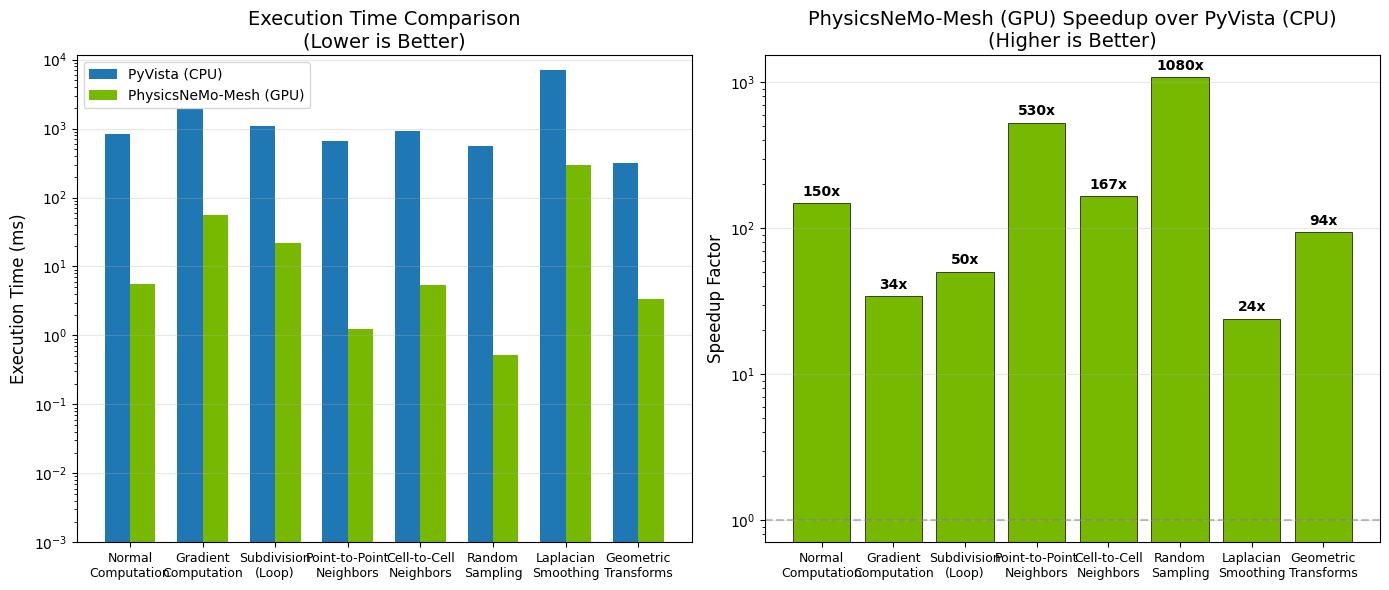


Benchmark visualization saved to benchmark_results.png


In [28]:
# Prepare data for visualization
# Use the largest mesh size from each benchmark for the summary

operations = []
pv_times = []
pnm_times = []
speedups = []

# Define which benchmarks to include and their display names
benchmark_configs = [
    ("normals", "Normal\nComputation"),
    ("gradient", "Gradient\nComputation"),
    ("subdivision", "Subdivision\n(Loop)"),
    ("neighbors_p2p", "Point-to-Point\nNeighbors"),
    ("neighbors_c2c", "Cell-to-Cell\nNeighbors"),
    ("sampling", "Random\nSampling"),
    ("smoothing", "Laplacian\nSmoothing"),
    ("transforms", "Geometric\nTransforms"),
]

for key, display_name in benchmark_configs:
    if key in benchmark_results and benchmark_results[key]["pyvista"]:
        # Use the last (largest) mesh size result
        pv_time = benchmark_results[key]["pyvista"][-1]
        pnm_time = (
            benchmark_results[key]["pnm_gpu"][-1]
            if benchmark_results[key]["pnm_gpu"]
            else pv_time
        )

        operations.append(display_name)
        pv_times.append(pv_time * 1000)  # Convert to ms
        pnm_times.append(pnm_time * 1000)
        speedups.append(pv_time / pnm_time if pnm_time > 0 else 1.0)

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# NVIDIA green color
nvidia_green = "#76B900"
pyvista_blue = "#1f77b4"

### Left plot: Execution time comparison (log scale) ###
x = np.arange(len(operations))
width = 0.35

bars1 = ax1.bar(
    x - width / 2, pv_times, width, label="PyVista (CPU)", color=pyvista_blue
)
bars2 = ax1.bar(
    x + width / 2, pnm_times, width, label="PhysicsNeMo-Mesh (GPU)", color=nvidia_green
)

ax1.set_ylabel("Execution Time (ms)", fontsize=12)
ax1.set_title("Execution Time Comparison\n(Lower is Better)", fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(operations, fontsize=9)
ax1.legend(loc="upper left")
ax1.set_yscale("log")
ax1.grid(axis="y", alpha=0.3)
ax1.set_ylim(bottom=0.001)

### Right plot: Speedup factors ###
bars3 = ax2.bar(x, speedups, color=nvidia_green, edgecolor="black", linewidth=0.5)

# Add speedup labels on top of bars
for bar, speedup in zip(bars3, speedups):
    height = bar.get_height()
    ax2.annotate(
        f"{speedup:.0f}x",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax2.set_ylabel("Speedup Factor", fontsize=12)
ax2.set_yscale("log")
ax2.set_title(
    "PhysicsNeMo-Mesh (GPU) Speedup over PyVista (CPU)\n(Higher is Better)", fontsize=14
)
ax2.set_xticks(x)
ax2.set_xticklabels(operations, fontsize=9)
ax2.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Baseline (1x)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nBenchmark visualization saved to benchmark_results.png")

### Key Takeaways

The benchmarks demonstrate several important points:

1. **Neighbor computation shows the largest speedups** - This is because PyVista/VTK only
   exposes per-element query functions, requiring O(n) Python calls with VTK overhead.
   PhysicsNeMo-Mesh computes all neighbors in a single vectorized GPU operation.

2. **Speedups increase with mesh size** - Larger meshes better amortize CUDA kernel launch
   overhead, showing the true GPU advantage for production workloads.

3. **Batch operations are key** - Operations like random sampling, where PyVista requires
   manual Python loops, show dramatic speedups when vectorized on GPU.

4. **Even simple operations benefit** - Normal computation and transformations, while fast
   on CPU, still see meaningful speedups on GPU - and these add up in training loops.

**For physics-AI pipelines**: When training on millions of mesh samples, even 10x speedups
in preprocessing translate to significant time and cost savings. More importantly, having
mesh operations on GPU enables:

- **On-the-fly feature engineering**: Compute geometric features during training, not just preprocessing
- **Differentiable mesh operations**: Backpropagate through mesh computations for end-to-end learning
- **Dynamic augmentation**: Apply random transformations without CPU-GPU transfer overhead

## Section 2: Batching Meshes for Training

When training with meshes of varying sizes, you need to handle dynamic shapes.
PhysicsNeMo-Mesh provides padding utilities for this.

In [15]:
# Use the bunny meshes at different subdivision levels (already created above)
batching_meshes = [meshes[0], meshes[1], meshes[2]]

print("Original mesh sizes:")
for i, m in enumerate(batching_meshes):
    print(f"  Mesh {i}: {m.n_points:,} points, {m.n_cells:,} cells")

Original mesh sizes:
  Mesh 0: 400 points, 796 cells
  Mesh 1: 1,594 points, 3,184 cells
  Mesh 2: 6,370 points, 12,736 cells


### Fixed-Size Padding

In [16]:
# Pad all meshes to fixed sizes
max_points = max(m.n_points for m in batching_meshes)
max_cells = max(m.n_cells for m in batching_meshes)

padded_meshes = [
    m.pad(target_n_points=max_points, target_n_cells=max_cells) for m in batching_meshes
]

print(f"\nPadded to {max_points:,} points, {max_cells:,} cells:")
for i, m in enumerate(padded_meshes):
    print(f"  Mesh {i}: {m.n_points:,} points, {m.n_cells:,} cells")


Padded to 6,370 points, 12,736 cells:
  Mesh 0: 6,370 points, 12,736 cells
  Mesh 1: 6,370 points, 12,736 cells
  Mesh 2: 6,370 points, 12,736 cells


### Power-Based Padding (for torch.compile)

For `torch.compile` with `dynamic=False`, pad to the next power of a base.
This limits the number of compiled kernel variants.

In [17]:
# Pad to next power of 1.5 (balances memory vs. compile cache hits)
power_padded = [m.pad_to_next_power(power=1.5) for m in batching_meshes]

print("Power-padded sizes:")
for i, (orig, padded) in enumerate(zip(batching_meshes, power_padded)):
    print(
        f"  Mesh {i}: {orig.n_points:,} -> {padded.n_points:,} points, "
        f"{orig.n_cells:,} -> {padded.n_cells:,} cells"
    )

Power-padded sizes:
  Mesh 0: 400 -> 437 points, 796 -> 985 cells
  Mesh 1: 1,594 -> 2,216 points, 3,184 -> 3,325 cells
  Mesh 2: 6,370 -> 7,481 points, 12,736 -> 16,834 cells


## Section 3: Feature Extraction for ML

Prepare geometric and physical features for model input.

In [18]:
def extract_features(mesh):
    """Extract features for an ML model."""
    features = TensorDict({}, batch_size=[mesh.n_points])

    # Geometric features
    features["position"] = mesh.points

    if mesh.codimension == 1:  # Surface mesh
        features["normal"] = mesh.point_normals
        features["gaussian_curvature"] = mesh.gaussian_curvature_vertices.unsqueeze(-1)
        features["mean_curvature"] = mesh.mean_curvature_vertices.unsqueeze(-1)

    return features

In [19]:
# Example: extract features from bunny mesh
bunny = torch.load("assets/bunny.pt", weights_only=False).subdivide(2, "loop")

features = extract_features(bunny)

print("Extracted features:")
for key in features.keys():
    print(f"  {key}: {features[key].shape}")

Extracted features:
  position: torch.Size([6370, 3])
  normal: torch.Size([6370, 3])
  gaussian_curvature: torch.Size([6370, 1])
  mean_curvature: torch.Size([6370, 1])


In [20]:
# Concatenate into feature matrix
feature_matrix = torch.cat(
    [
        features["position"],
        features["normal"],
        features["gaussian_curvature"],
        features["mean_curvature"],
    ],
    dim=-1,
)

print(f"Feature matrix: {feature_matrix.shape}")
print(f"  (n_points, n_features)")

Feature matrix: torch.Size([6370, 8])
  (n_points, n_features)


## Section 4: Boundary Condition Handling

A key advantage of PhysicsNeMo-Mesh is the ability to store rich metadata,
including boundary condition information.

In [21]:
# Example: CFD mesh with boundary conditions (using bunny mesh)
bc_mesh = meshes[2].clone()  # Use level 2 bunny

# Define BC types
BC_INTERIOR = 0
BC_INLET = 1
BC_OUTLET = 2
BC_WALL = 3

# Assign BC types based on position (example)
# Bunny is roughly centered, so we use quantiles to define boundaries
x = bc_mesh.points[:, 0]
x_min, x_max = x.min(), x.max()
x_range = x_max - x_min

bc_type = torch.full((bc_mesh.n_points,), BC_INTERIOR, dtype=torch.long)
bc_type[x < x_min + 0.15 * x_range] = BC_INLET
bc_type[x > x_max - 0.15 * x_range] = BC_OUTLET
bc_type[
    (x >= x_min + 0.15 * x_range)
    & (x <= x_max - 0.15 * x_range)
    & (bc_mesh.points[:, 2] < bc_mesh.points[:, 2].median())
] = BC_WALL

bc_mesh.point_data["bc_type"] = bc_type

print("Boundary condition counts:")
for name, val in [("Interior", 0), ("Inlet", 1), ("Outlet", 2), ("Wall", 3)]:
    count = (bc_type == val).sum().item()
    print(f"  {name}: {count}")

Boundary condition counts:
  Interior: 2651
  Inlet: 138
  Outlet: 1102
  Wall: 2479


In [22]:
# Visualize BC types
bc_mesh.draw(point_scalars="bc_type", cmap="Set1", show_edges=False)

Widget(value='<iframe src="http://localhost:46427/index.html?ui=P_0x7296d90442f0_0&reconnect=auto" class="pyvi…

In [23]:
# Store BC values in nested TensorDict
bc_mesh.point_data["bc_values"] = TensorDict(
    {
        "velocity": torch.zeros(bc_mesh.n_points, 3),
        "pressure": torch.full((bc_mesh.n_points,), float("nan")),
    },
    batch_size=[bc_mesh.n_points],
)

# Set inlet velocity (1 m/s in x-direction)
inlet_mask = bc_mesh.point_data["bc_type"] == BC_INLET
bc_mesh.point_data["bc_values", "velocity"][inlet_mask] = torch.tensor([1.0, 0.0, 0.0])

# Set outlet pressure (0 Pa gauge)
outlet_mask = bc_mesh.point_data["bc_type"] == BC_OUTLET
bc_mesh.point_data["bc_values", "pressure"][outlet_mask] = 0.0

print(f"Mesh with BCs: {bc_mesh}")

Mesh with BCs: Mesh(manifold_dim=2, spatial_dim=3, n_points=6370, n_cells=12736)
    point_data : {
        bc_type     : (),
        bc_values   : {pressure: (), velocity: (3,)},
        scalar_field: (),
        _cache      : {gaussian_curvature: ()}}
    cell_data  : {_cache: {areas: ()}}
    global_data: {}


## Section 5: End-to-End CAE Workflow

Complete example: load mesh, extract features, prepare for GNN training.

In [24]:
def prepare_mesh_for_training(mesh, device="cpu"):
    """
    Prepare a mesh for GNN training.

    Returns:
        node_features: (n_nodes, n_features)
        edge_index: (2, n_edges)
        edge_features: (n_edges, n_edge_features)
    """
    mesh = mesh.to(device)

    ### Node features: position + geometric features
    node_features = [mesh.points]

    if mesh.codimension == 1:
        node_features.append(mesh.point_normals)
        node_features.append(mesh.gaussian_curvature_vertices.unsqueeze(-1))
        node_features.append(mesh.mean_curvature_vertices.unsqueeze(-1))

    node_features = torch.cat(node_features, dim=-1)

    ### Edge index from mesh adjacency
    adj = mesh.get_point_to_points_adjacency()
    neighbor_counts = adj.offsets[1:] - adj.offsets[:-1]
    source = torch.repeat_interleave(
        torch.arange(mesh.n_points, device=device), neighbor_counts
    )
    target = adj.indices
    edge_index = torch.stack([source, target], dim=0)

    ### Edge features: relative position, distance
    edge_vectors = mesh.points[target] - mesh.points[source]
    edge_lengths = edge_vectors.norm(dim=-1, keepdim=True)
    edge_features = torch.cat([edge_vectors, edge_lengths], dim=-1)

    return {
        "node_features": node_features,
        "edge_index": edge_index,
        "edge_features": edge_features,
        "n_nodes": mesh.n_points,
        "n_edges": edge_index.shape[1],
    }

In [25]:
# Example usage
bunny = torch.load("assets/bunny.pt", weights_only=False).subdivide(2, "loop")

device = "cuda" if torch.cuda.is_available() else "cpu"
graph_data = prepare_mesh_for_training(bunny, device=device)

print("GNN-ready data:")
for key, value in graph_data.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key}: {value.shape} on {value.device}")
    else:
        print(f"  {key}: {value}")

GNN-ready data:
  node_features: torch.Size([6370, 8]) on cuda:0
  edge_index: torch.Size([2, 38208]) on cuda:0
  edge_features: torch.Size([38208, 4]) on cuda:0
  n_nodes: 6370
  n_edges: 38208


## Section 6: torch.compile Compatibility

Most PhysicsNeMo-Mesh operations are compatible with `torch.compile`.

In [26]:
if torch.cuda.is_available():

    @torch.compile
    def compute_features_compiled(points, cells):
        """Compiled feature computation."""
        m = Mesh(points=points, cells=cells)
        normals = m.cell_normals
        areas = m.cell_areas
        return normals, areas

    # Use the bunny mesh on GPU
    compile_mesh = meshes[2].to("cuda")  # Level 2 bunny

    print("Testing torch.compile...")
    normals, areas = compute_features_compiled(compile_mesh.points, compile_mesh.cells)
    print(f"  Normals: {normals.shape}")
    print(f"  Areas: {areas.shape}")
    print("  Success!")
else:
    print("CUDA not available - skipping torch.compile demo")

Testing torch.compile...
  Normals: torch.Size([12736, 3])
  Areas: torch.Size([12736])
  Success!


## Summary

In this tutorial, you learned about ML integration:

1. **Performance Benchmarks**: Comprehensive comparison of PhysicsNeMo-Mesh (GPU) vs PyVista/VTK (CPU)
   - Normal computation, curvature, subdivision, neighbor queries
   - Random sampling, Laplacian smoothing, geometric transformations
   - Neighbor computation shows the largest speedups due to vectorized vs per-element APIs
2. **Batching**: `pad()` and `pad_to_next_power()` for dynamic shapes with torch.compile
3. **Feature Extraction**: Geometric features (normals, curvature) for model input
4. **Boundary Conditions**: Nested TensorDict for rich metadata storage
5. **End-to-End**: Complete workflow from mesh to GNN-ready data
6. **torch.compile**: Most operations are compilation-compatible

---

### Key Takeaway

PyVista and VTK are excellent tools for visualization and interactive exploration. However,
for large-scale physics-AI training pipelines, their CPU-bound nature and per-element APIs
create bottlenecks. PhysicsNeMo-Mesh addresses this by providing:

- **Vectorized GPU operations**: Compute all neighbors, samples, or features in one kernel
- **Differentiable mesh processing**: Enable end-to-end learning through mesh operations
- **On-the-fly feature engineering**: Compute geometric features during training, not just preprocessing

This enables new physics-aware model architectures that were previously impractical.

---

### Conclusion

You've completed the PhysicsNeMo-Mesh tutorial series! You now know how to:

- Create, load, and manipulate meshes
- Perform geometric transformations and subdivision
- Compute gradients, divergence, curl, and curvature
- Query neighbors and perform spatial searches
- Validate and repair meshes
- Integrate meshes into high-performance ML training pipelines

For more details, see the [physicsnemo.mesh README](../../../physicsnemo/mesh/README.md).